<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20ECO002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

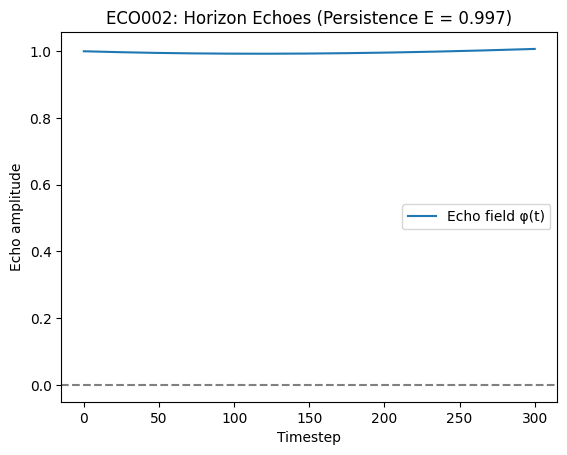

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
M = 10.0
alpha = 0.16
beta = 0.06
gamma = 0.2
R_c = 1.5
delta = 0.1
eta = 0.5
timesteps = 300

def S(R): return gamma * np.log(1 + R/R_c)
def dS_dR(R): return gamma / (R + R_c)
def collapse_step(R): return R - alpha * M / (R**2) + beta * S(R)

# Initialize
R_vals = [10.0]
phi_vals = [1.0]  # initial echo field

# Simulate
for t in range(timesteps):
    R_next = max(collapse_step(R_vals[-1]), R_c)
    phi_next = phi_vals[-1] + delta * (-phi_vals[-1]/R_next**2 + eta * dS_dR(R_next))
    R_vals.append(R_next)
    phi_vals.append(phi_next)

# Echo persistence metric
E = np.mean(np.abs(phi_vals))

# Plot
plt.plot(phi_vals, label="Echo field φ(t)")
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Timestep")
plt.ylabel("Echo amplitude")
plt.title(f"ECO002: Horizon Echoes (Persistence E = {E:.3f})")
plt.legend()
plt.show()
